In [1]:
from utils import *
from plotting import *
from visualisations import *
import sympy as sp

saver = FigureSaver(base_folder="figures/PartII/Schwarzschild", fmt="pdf", dpi=400, timestamp=False)

## 2. Schwarzschild spacetime

We now consider the Schwarzschild metric,
a static, spherically symmetric vacuum solution describing the gravitational field outside a non-rotating, uncharged mass $M$.

In Schwarzschild coordinates $(t, r, \theta, \phi)$ the line element is
$$
ds^2 = -\left(1-\frac{2M}{r}\right) dt^2
       + \left(1-\frac{2M}{r}\right)^{-1} dr^2
       + r^2 (d\theta^2 + \sin^2\theta\, d\phi^2).
$$

This geometry is Ricci-flat ($R_{\mu\nu}=0$) but not conformally flat, so the Weyl tensor is non-zero and encodes the curvature produced by the central mass.

---

### Observers

We will consider two observers:

1. **Static observer** at fixed $(r,\theta,\phi)$  
   whose 4-velocity has only a time component:
   $$
   u^{\mu}_{\text{stat}} = (u^t, 0, 0, 0), \qquad
   u^t = \frac{1}{\sqrt{1-2M/r}}.
   $$

    A timelike observer can only be defined outside the Schwarzschild radius $r_{S}=2M$. 

3. **Circular orbit observer** moving with constant angular velocity $\Omega$ (equatorial $\theta=\pi/2$):
   $$
   u^{\mu}_{\text{circ}} = u^t (1, 0, 0, \Omega), \qquad
   u^t = \frac{1}{\sqrt{1-2M/r - \Omega^2 r^2}}.
   $$
   The normalization $g_{\mu\nu}u^\mu u^\nu=-1$ fixes $u^t$.

   We note that, for timelike observers, exists an innermost stable circular orbit given by $r_{ISCO}=6M$.
   
In what follows we will compute the Weyl tensor for the Schwarzschild metric
and then evaluate its electric and magnetic parts ($E_{ab}$ and $B_{ab}$)
for both observers, along with the corresponding invariants and Bel–Robinson quantities.


In [2]:
# --- coordinates and parameters ---
t, r, th, ph, M, Omega = sp.symbols("t r theta phi M Omega", real=True)
coords = (t, r, th, ph)

# --- 3. Schwarzschild metric ---
f = 1 - 2*M/r
g_cov = sp.Matrix([
    [-f,     0,           0,                0],
    [ 0, 1/f,           0,                0],
    [ 0,     0,       r**2,                0],
    [ 0,     0,           0,  r**2*sp.sin(th)**2]
])
metric = metric_from_components(g_cov, coords)

# --- Observer 4-velocities ---
# (a) Static observer
u_stat_contra = sp.Matrix([1/sp.sqrt(f), 0, 0, 0])
u_stat_cov = g_cov * u_stat_contra

# (b) Circular orbit observer
u_circ_contra = sp.Matrix([
    1/sp.sqrt(f - Omega**2 * r**2 ),
    0, 0,
    Omega/sp.sqrt(f - Omega**2 * r**2 )
])
u_circ_cov = g_cov * u_circ_contra

display(Math(r"u_{\text{stat},\mu} = " + sp.latex(u_stat_cov)))
display(Math(r"u_{\text{circ},\mu} = " + sp.latex(u_circ_cov)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
# --- Compute Weyl tensor for Schwarzschild metric ---
C = weyl_from_metric(metric)

# --- Print nonzero, unique components only ---
print("Nonzero unique Weyl tensor components for Schwarzschild:")
print_tensor_components(C, name="C")

Nonzero unique Weyl tensor components for Schwarzschild:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
J1, J2 = weyl_invariants(C, metric, convention="raw", show_results=True)  

<IPython.core.display.Math object>

### Part 1: Static observer.

In [5]:
# --- E, B and eigenproblem for the static observer ---
E_stat, B_stat = electric_magnetic_weyl(C, metric, u_stat_cov)

# trace check (STF property)
check_trace(E_stat, B_stat, metric)

# eigenstructure
eig_stat = eigenstructure_EB(E_stat, B_stat, show_vectors=True)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

trace(E) = 0
trace(B) = 0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
EB_stat = norm_EB(E_stat, B_stat, metric)
E2_stat = sp.simplify(EB_stat["E2"])
B2_stat = sp.simplify(EB_stat["B2"])

<IPython.core.display.Math object>

In [7]:
br_stat = bel_robinson_observer(C, metric, u_stat_cov, show_results=True)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Part 2: Rotating observer.

In [8]:
# --- E, B and eigenproblem for the static observer ---
E_circ, B_circ = electric_magnetic_weyl(C, metric, u_circ_cov)

# trace check (STF property)
check_trace(E_circ, B_circ, metric)

# eigenstructure
eig_stat = eigenstructure_EB(E_circ, B_circ, show_vectors=True)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

trace(E) = 0
trace(B) = 0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
EB_circ = norm_EB(E_circ, B_circ, metric, show_results=True)
E2_circ = sp.simplify(EB_circ["E2"])
B2_circ = sp.simplify(EB_circ["B2"])

<IPython.core.display.Math object>

In [10]:
br_circ = bel_robinson_observer(C, metric, u_circ_cov, show_results=True)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Part 3: Null tetrad.

## Kinnersley tetrad and its Schwarzschild limit

In studying radiative perturbations of Kerr spacetime, Teukolsky (1973) introduced a particular Newman–Penrose null tetrad known as the **Kinnersley tetrad**.  
It is aligned with the two repeated principal null directions of the Weyl tensor, and is therefore naturally adapted to **Petrov type D** geometries.

For the Kerr metric in Boyer–Lindquist coordinates $(t,r,\theta,\phi)$, the Kinnersley tetrad is conventionally written as

$$
\begin{aligned}
l^\mu &= \left[\frac{r^2 + a^2}{\Delta},\; 1,\; 0,\; \frac{a}{\Delta}\right], \\
n^\mu &= \frac{1}{2\Sigma}\left[r^2 + a^2,\; -\Delta,\; 0,\; a\right], \\
m^\mu &= \frac{1}{\sqrt{2}(r + i a \cos\theta)}\left[i a \sin\theta,\; 0,\; 1,\; \frac{i}{\sin\theta}\right],
\end{aligned}
$$

where

$$
\Sigma = r^2 + a^2\cos^2\theta, \qquad \Delta = r^2 - 2Mr + a^2.
$$

This tetrad is **gauged** (or “Kinnersley normalized”) so that

$$
l_\mu n^\mu = -1, \qquad m_\mu \bar{m}^\mu = 1,
$$

and all other scalar products vanish. With this choice, the only non-zero Newman–Penrose Weyl scalar is

$$
\psi_2 = -\frac{M}{(r - i a \cos\theta)^3},
$$

confirming the type D nature of the Kerr solution.

---

### Schwarzschild limit

In the Schwarzschild limit ($a \to 0$), the tetrad simplifies to

$$
l^\mu = \left[\frac{r^2}{\Delta},\; 1,\; 0,\; 0\right], \quad
n^\mu = \frac{1}{2r^2}\left[r^2,\; -\Delta,\; 0,\; 0\right], \quad
m^\mu = \frac{1}{\sqrt{2}r}\left[0,\; 0,\; 1,\; \frac{i}{\sin\theta}\right],
$$

with $\Delta = r^2 - 2Mr$.  
This is the **Kinnersley tetrad for Schwarzschild**, still aligned with the principal null directions and preserving the same normalization and type D character.  
The only non-vanishing Weyl scalar remains

$$
\psi_2 = -\frac{M}{r^3},
$$

while all other $\psi_i$ vanish.

---

*Source: Teukolsky, S.A. “Perturbations of a rotating black hole. I. Fundamental equations for gravitational, electromagnetic, and neutrino-field perturbations.” ApJ **185** (1973) 635.*


In [11]:
# --- define null tetrad (Kinnersley form, Schwarzschild limit) ---

# coordinates and functions
f = 1 - 2*M/r
Delta = r**2 - 2*M*r

l_vec = sp.Matrix([r**2/Delta, 1, 0, 0])
n_vec = sp.Matrix([1/2, -f/2, 0, 0])
m_vec = sp.Matrix([0, 0, 1/(sp.sqrt(2)*r), sp.I/(sp.sqrt(2)*r*sp.sin(th))])
mb_vec = sp.conjugate(m_vec)

tetrad = {"l": l_vec, "n": n_vec, "m": m_vec, "mbar": mb_vec}

In [12]:
# --- compute NP Weyl scalars ---
Psi = np_scalars_from_weyl(C, tetrad, show_results=True)

<IPython.core.display.Math object>

### Part 4: Visualizations on equatorial $\theta=\pi/2$ slice.

[FigureSaver] Saved figure → figures/PartII/Schwarzschild\E2 - Static Observer.pdf


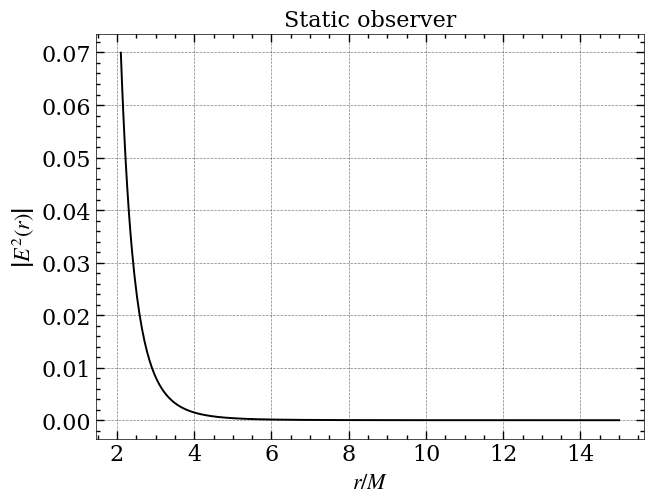

In [13]:
plot_scalar_vs_r(E2_stat, r, {M:1, th:sp.pi/2}, label=r"$\left|E^{2}(r)\right|$", title="Static observer", orbit_type="stat")
saver.save("E2 - Static Observer")
plt.show()

[FigureSaver] Saved figure → figures/PartII/Schwarzschild\E2, B2 - Circular Observer.pdf


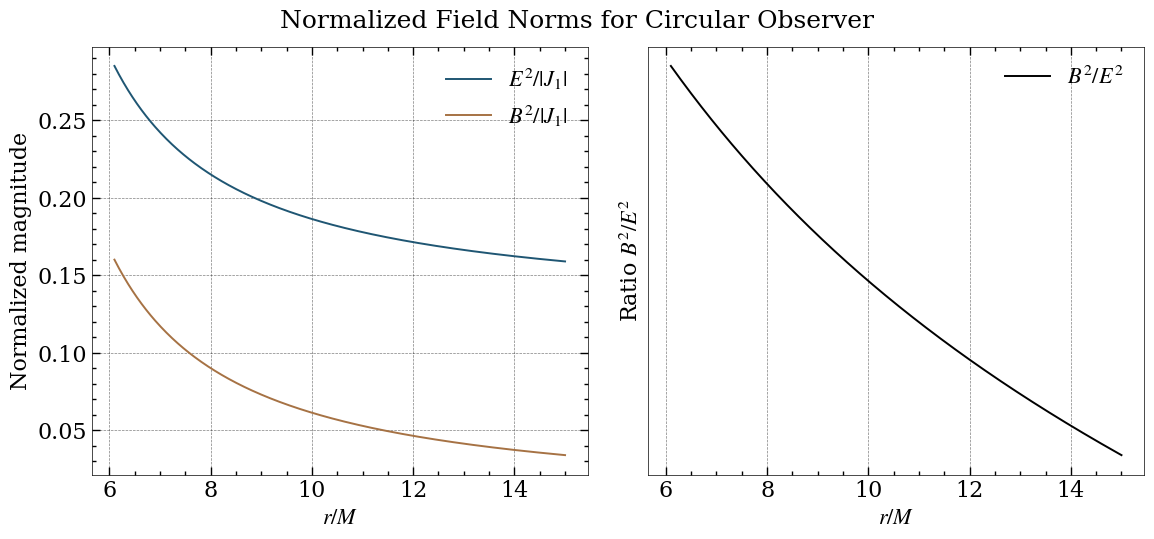

In [14]:
plot_compare_normalized_by_J1(
    E2_circ,
    B2_circ,
    J1,
    r,
    subs_dict={M:1, th:sp.pi/2, Omega:1/sp.sqrt(r**3)},
    r_range=(6.1, 15),
    title="Normalized Field Norms for Circular Observer",
    J1_behavior="positive"
)
saver.save("E2, B2 - Circular Observer")
plt.show()

[FigureSaver] Saved figure → figures/PartII/Schwarzschild\E_stat - Tensor Heatmap.pdf


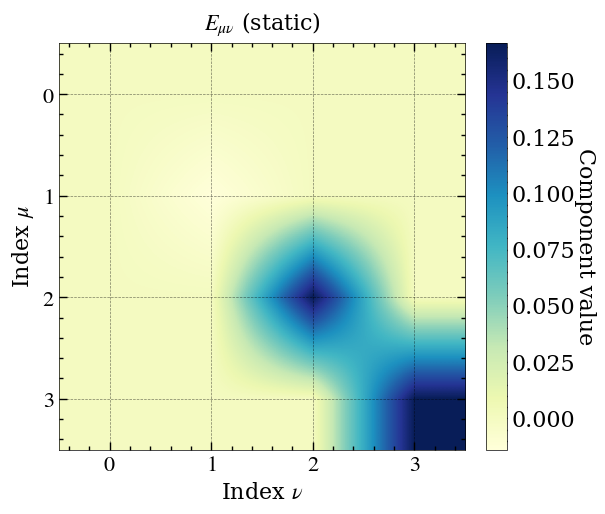

[FigureSaver] Saved figure → figures/PartII/Schwarzschild\E_circ - Tensor Heatmap.pdf


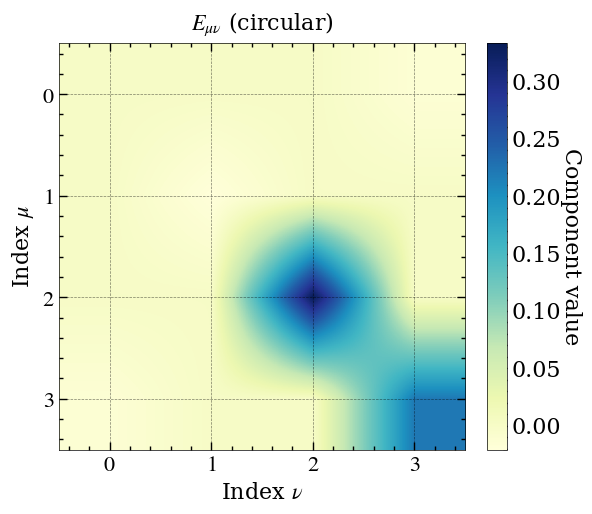

[FigureSaver] Saved figure → figures/PartII/Schwarzschild\B_circ - Tensor Heatmap.pdf


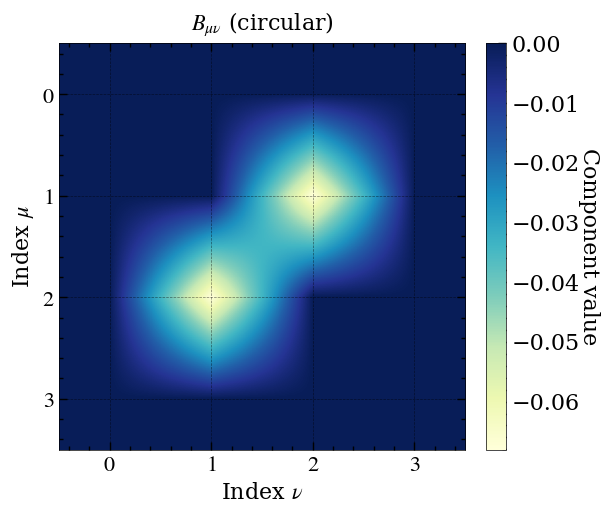

In [15]:
cmap = "YlGnBu"

plot_tensor_matrix(E_stat, {M:1, th:sp.pi/2, r:6}, r_val=6, title=r"$E_{\mu\nu}$ (static)", cmap=cmap)
saver.save("E_stat - Tensor Heatmap")
plt.show()
plot_tensor_matrix(E_circ, {M:1, th:sp.pi/2, Omega:1/sp.sqrt(r**3), r:6}, r_val=6, title=r"$E_{\mu\nu}$ (circular)", cmap=cmap)
saver.save("E_circ - Tensor Heatmap")
plt.show()
plot_tensor_matrix(B_circ, {M:1, th:sp.pi/2, Omega:1/sp.sqrt(r**3), r:6}, r_val=6, title=r"$B_{\mu\nu}$ (circular)", cmap=cmap)
saver.save("B_circ - Tensor Heatmap")
plt.show()